## Feature Engineering

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_EDA = pd.read_csv('df_EDA.csv')
df_EDA

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted,age_group,campaign_group,previous_group
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,51-60,1-2,0 (Never Contacted)
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,51-60,1-2,0 (Never Contacted)
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,31-40,1-2,0 (Never Contacted)
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,31-40,1-2,0 (Never Contacted)
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,51-60,1-2,0 (Never Contacted)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41171,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,1,0,60+,1-2,0 (Never Contacted)
41172,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,0,0,41-50,1-2,0 (Never Contacted)
41173,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,0,0,51-60,1-2,0 (Never Contacted)
41174,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,1,0,41-50,1-2,0 (Never Contacted)


In [3]:
# Age group
df_EDA['age_group'] = pd.cut(
    df_EDA['age'],
    bins=[17,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

In [4]:
# Campaign group
df_EDA['campaign_group'] = pd.cut(
    df_EDA['campaign'],
    bins=[0,2,5,10,100],
    labels=['1-2','3-5','6-10','10+']
)

In [5]:
# Previous contact
df_EDA['previous_contact_flag'] = df_EDA['previous'].apply(lambda x: 0 if x==0 else 1)

In [6]:
# Check df
df_EDA

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted,age_group,campaign_group,previous_group,previous_contact_flag
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,51-60,1-2,0 (Never Contacted),0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,51-60,1-2,0 (Never Contacted),0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,31-40,1-2,0 (Never Contacted),0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,31-40,1-2,0 (Never Contacted),0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,51-60,1-2,0 (Never Contacted),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41171,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,94.767,-50.8,1.028,4963.6,1,0,60+,1-2,0 (Never Contacted),0
41172,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,94.767,-50.8,1.028,4963.6,0,0,41-50,1-2,0 (Never Contacted),0
41173,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,94.767,-50.8,1.028,4963.6,0,0,51-60,1-2,0 (Never Contacted),0
41174,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,94.767,-50.8,1.028,4963.6,1,0,41-50,1-2,0 (Never Contacted),0


# Modelling

In [7]:
# Train test split
from sklearn.model_selection import train_test_split

X = df_EDA.drop('y', axis=1)
y = df_EDA['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# Preprocessing kategorikal dan numerikal
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_cols = X.select_dtypes(include=['object','category']).columns
numerical_cols = X.select_dtypes(exclude=['object','category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

# Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.66      0.22      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.64      8236
weighted avg       0.88      0.90      0.88      8236

ROC-AUC: 0.8008561561019573


# Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7308
           1       0.56      0.29      0.38       928

    accuracy                           0.89      8236
   macro avg       0.74      0.63      0.66      8236
weighted avg       0.87      0.89      0.88      8236

ROC-AUC: 0.7752115802474379


# Xgboost

In [11]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7308
           1       0.60      0.28      0.38       928

    accuracy                           0.90      8236
   macro avg       0.76      0.63      0.66      8236
weighted avg       0.88      0.90      0.88      8236

ROC-AUC: 0.7935825229318838


In [12]:
# Table comparison Logistic Regression, Random Forest, XGBOOST

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Hasil evaluasi model
model_results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.90, 0.89, 0.90],
    "Precision (Yes)": [0.66, 0.56, 0.60],
    "Recall (Yes)": [0.22, 0.29, 0.28],
    "F1-Score (Yes)": [0.32, 0.38, 0.38],
    "ROC-AUC": [0.8008561561019573, 0.7752115802474379, 0.7935825229318838]
}

comparison_table = pd.DataFrame(model_results)

comparison_table = comparison_table.sort_values(by="ROC-AUC", ascending=False)

print(comparison_table)

                 Model  Accuracy  Precision (Yes)  Recall (Yes)  \
0  Logistic Regression      0.90             0.66          0.22   
2              XGBoost      0.90             0.60          0.28   
1        Random Forest      0.89             0.56          0.29   

   F1-Score (Yes)   ROC-AUC  
0            0.32  0.800856  
2            0.38  0.793583  
1            0.38  0.775212  


INSIGHT:

- Logistic Regression memiliki performa terbaik dengan ROC-AUC tertinggi (0.80), paling baik dalam membedakan nasabah yang akan subscribe dan tidak.

- XGBoost dan Random Forest memiliki F1-score lebih tinggi (0.38) dibanding Logistic Regression ini menunjukkan keseimbangan precision dan recall yang lebih baik.

- Random Forest memiliki recall tertinggi (0.29) yang berarti lebih mampu menangkap nasabah yang benar benar akan subscribe.

- Perbedaan performa antar model relatif kecil menunjukkan pola pada dataset tidak terlalu kompleks.

- Berdasarkan ROC-AUC tertinggi dan model yang lebih sederhana, Logistic Regression dipilih sebagai model utama.


# Perbandingan antar model

/tmp/ipykernel_658/3493509925.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ROC_AUC', y='Model', data=results, palette='viridis')


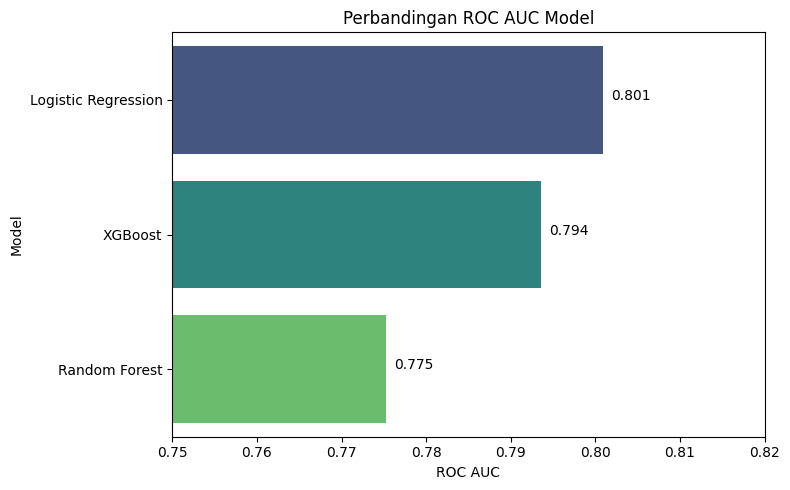

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC_AUC': [0.800856, 0.775212, 0.793583]
})

# Urutkan berdasarkan ROC_AUC
results = results.sort_values(by='ROC_AUC', ascending=False)

# Visualisasi
plt.figure(figsize=(8,5))
sns.barplot(x='ROC_AUC', y='Model', data=results, palette='viridis')
plt.xlim(0.75, 0.82)
plt.title('Perbandingan ROC AUC Model')
plt.xlabel('ROC AUC')
plt.ylabel('Model')
for index, value in enumerate(results['ROC_AUC']):
    plt.text(value + 0.001, index, f"{value:.3f}")
plt.tight_layout()
plt.show()

Logistic Regression

    ROC-AUC: 0.8008561561019573

Random Forest

    ROC-AUC: 0.7752115802474379

XGBOOST

    ROC-AUC: 0.7935825229318838



INSIGHTS:

  - Logistic Regression memberikan performa terbaik.
  - Perbedaan antar model relatif kecil, pola data tidak terlalu kompleks.
  - ROC_AUC Logistic (0.800856) berarti model memiliki kemampuan 80% dalam membedakan nasabah yang akan subscribe dan tidak.


## Tuning Logical Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# Pipeline model
log_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Training
log_model.fit(X_train, y_train)

# Predict
y_pred_before = log_model.predict(X_test)
y_prob_before = log_model.predict_proba(X_test)[:,1]

# Evaluation
print("=== Logistic Regression Before Tuning ===")
print(classification_report(y_test, y_pred_before))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_before))

=== Logistic Regression Before Tuning ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.66      0.22      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.64      8236
weighted avg       0.88      0.90      0.88      8236

ROC-AUC: 0.8008561561019573


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear']
}

grid_log = GridSearchCV(
    log_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best Parameters:", grid_log.best_params_)

Best Parameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}


In [16]:
# Model setelah tuning
best_log_model = grid_log.best_estimator_

y_pred_after = best_log_model.predict(X_test)
y_prob_after = best_log_model.predict_proba(X_test)[:,1]

print("=== Logistic Regression After Tuning ===")
print(classification_report(y_test, y_pred_after))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_after))

=== Logistic Regression After Tuning ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.66      0.21      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.63      8236
weighted avg       0.88      0.90      0.88      8236

ROC-AUC: 0.8007047219155201


In [17]:
# Perbandingan before and after tuning
comparison = pd.DataFrame({
    "Model": ["Before Tuning", "After Tuning"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_before),
        roc_auc_score(y_test, y_prob_after)
    ]
})

print(comparison)

           Model   ROC-AUC
0  Before Tuning  0.800856
1   After Tuning  0.800705




INSIGHTS:

  - Hyperparameter tuning dilakukan pada Logistic Regression untuk mencari parameter terbaik menggunakan GridSearchCV.
  - Baseline Logistic Regression menghasilkan ROC-AUC sekitar 0.800856
  - Setelah tuning parameter C dan solver, performa model sedikit meningkat 0.800705
  - Model dengan parameter terbaik digunakan sebagai final model

===========================================================================================================


## Feature Importance

In [18]:
# Ambil nama fitur setelah preprocessing
feature_names = best_log_model.named_steps['prep'].get_feature_names_out()

# Ambil koefisien model
coefficients = best_log_model.named_steps['model'].coef_[0]

# Buat dataframe feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# Urutkan berdasarkan pengaruh terbesar
feature_importance = feature_importance.sort_values(
    by='Importance',
    key=abs,
    ascending=False
)

print(feature_importance.head(10))

                   Feature  Importance
69       num__emp.var.rate   -1.290822
40          cat__month_mar    1.019060
70     num__cons.price.idx    0.669856
41          cat__month_may   -0.581619
42          cat__month_nov   -0.416989
34  cat__contact_telephone   -0.326489
39          cat__month_jun   -0.314592
37          cat__month_dec    0.305809
50   cat__poutcome_failure   -0.302531
33   cat__contact_cellular    0.290553


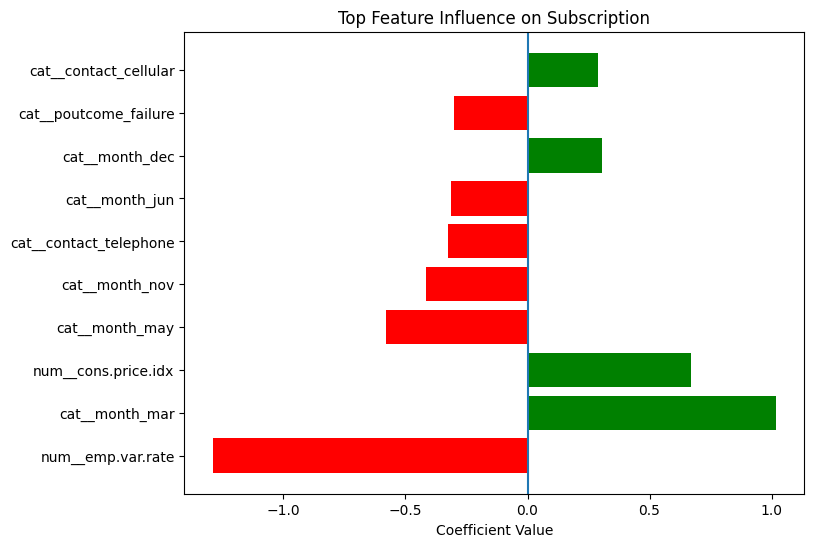

In [19]:
# Visualisasi feature importance
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

colors = ['green' if c > 0 else 'red' for c in top_features['Importance']]

plt.barh(top_features['Feature'], top_features['Importance'], color=colors)

plt.axvline(0)

plt.title("Top Feature Influence on Subscription")
plt.xlabel("Coefficient Value")

plt.show()

INSIGHTS:

  - emp.var.rate memiliki pengaruh negatif paling besar terhadap subscription. Artinya ketika indikator kondisi ekonomi ini meningkat kemungkinan nasabah melakukan subscription cenderung menurun.
  - month_mar memiliki pengaruh positif paling kuat menunjukkan bahwa campaign yang dilakukan pada bulan Maret memiliki peluang konversi lebih tinggi dibanding bulan lainnya.
  - cons.price.idx berpengaruh positif terhadap subscription yang mengindikasikan kondisi ekonomi tertentu dapat meningkatkan minat nasabah untuk mengambil produk deposito.
  - Metode kontak melalui cellular meningkatkan peluang subscription sehingga penggunaan telepon seluler lebih efektif dibanding metode kontak lainnya.
  - Hasil campaign sebelumnya poutcome_failure berdampak negatif menunjukkan bahwa nasabah yang sebelumnya gagal dalam campaign cenderung memiliki kemungkinan lebih kecil untuk melakukan subscription di campaign berikutnya.
  - Beberapa bulan seperti May, November, dan June memiliki pengaruh negatif yang menunjukkan periode tersebut kurang efektif untuk melakukan campaign marketing.


# Rekomendasi


- Prioritaskan nasabah dengan riwayat campaign berhasil Nasabah dengan previous campaign success memiliki kemungkinan konversi jauh lebih tinggi sehingga follow up ke segmen ini perlu diprioritaskan.

- Batasi frekuensi kontak ke nasabah Terlalu sering menghubungi nasabah justru menurunkan conversion rate sehingga jumlah kontak sebaiknya dibatasi (misalnya maksimal <3 kali).

- Optimalkan timing campaign Beberapa bulan memiliki performa campaign lebih tinggi (Maret) sehingga alokasi budget dan aktivitas marketing sebaiknya difokuskan pada bulan tersebut.

- Gunakan metode kontak yang lebih efektif Kontak melalui mobile phone terbukti meningkatkan peluang subscription dibandingkan metode lain seperti telephone rumah.

- Perhatikan kondisi ekonomi saat menjalankan campaign Faktor ekonomi seperti emp.var.rate dan cons.price.idx mempengaruhi peluang subscription sehingga strategi campaign perlu menyesuaikan dari segi kondisi ekonomi.

- Implementasikan Logistic Regression untuk lead scoring Model Logistic Regression dengan ROC-AUC 0.80 dapat digunakan untuk memberi skor probabilitas nasabah melakukan subscription sehingga tim marketing dapat fokus menghubungi top 40% prospek dengan peluang tertinggi untuk meningkatkan pengurangan biaya campaign dan ROI.



Tujuan Project

Menganalisis faktor yang mempengaruhi keputusan nasabah melakukan subscription serta membangun model prediksi untuk meningkatkan efektivitas campaign marketing.

Temuan Utama dari EDA

    - Faktor demografis seperti job, education, dan age group mempengaruhi tingkat conversion.
    - Frekuensi kontak yang terlalu sering justru menurunkan peluang nasabah untuk subscribe.
    - Bulan tertentu (March, December, September) memiliki tingkat subscription lebih tinggi sehingga timing campaign menjadi faktor penting.
    - Riwayat keberhasilan campaign sebelumnya merupakan indikator terkuat dalam keberhasilan campaign berikutnya.

Modeling

    - Logistic Regression menjadi model terbaik dengan ROC-AUC 0.80.
    - Model ini mampu membedakan nasabah yang berpotensi subscribe dan tidak dengan cukup baik.

Business Impact Dengan menggunakan model prediktif ini, perusahaan dapat memprioritaskan nasabah dengan kemungkinan subscription lebih tinggi sehingga campaign menjadi lebih terarah. Strategi ini membantu mengurangi biaya marketing pada prospek dengan peluang rendah, meningkatkan conversion rate, serta mengoptimalkan alokasi budget campaign untuk mendapatkan ROI yang lebih maksimal.